## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
from scipy import fftpack
import glob
import os
import json
import time
from pprint import pprint

# Import tensorflow packages
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, TimeDistributed, Masking, Activation, BatchNormalization, ReLU, GlobalAveragePooling1D, Permute, TimeDistributed
from tensorflow.keras.layers import Input, LSTM, MaxPooling1D, Conv1D, Bidirectional, GlobalMaxPooling1D, Attention, AdditiveAttention, multiply, concatenate, Reshape, GRU, Concatenate
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam


from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler
from scipy.ndimage import gaussian_filter1d

import warnings
warnings.filterwarnings("ignore")

np.random.seed(2022)

## Mount the Google Drive

> Get access to read and write files in google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Path in Google Drive

> Show the full path of the data folder in google drive

In [3]:
data_folder = '/content/drive/MyDrive/My Projects/[Gym Exersices Classification]/data/'
features = ['accX', 'accY', 'accZ', 'accMag','orientationX', 'orientationY', 'orientationZ', 'orientationMag']
labels = {}
inv_labels = {}
for i, ex in enumerate(sorted(os.listdir(data_folder))):
    labels[ex] = i
    inv_labels[i] = ex

# Loading pretrained Gym Exercise Classification Model 

In [4]:
# Load TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/My Projects/[Gym Exersices Classification]/model.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_shape = input_details[0]['shape']

def tflite_model_prediction(data, thresh = 0.6):
    preds = []
    pred_probs = []
    for x in data:
        inp = x.reshape(1, 30, 8)
        input_data = np.array(inp, dtype=np.float32)
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])
        if max(output_data[0]) >= thresh:
            preds.append(output_data[0].argmax())
            pred_probs.append(max(output_data[0]))
        else:
            preds.append(-1)
            pred_probs.append(-1)

    return np.asarray(preds), np.asarray(pred_probs)

def model_prediction(model,
                     input_data,
                     thresh = 0.6
                     ):
    predict_probability = model.predict(input_data)

    predict = np.argmax(predict_probability, axis=1)
    for i, mx in enumerate(np.max(predict_probability, axis=1)):
        if mx<thresh:
            predict[i]=-1

    return predict, predict_probability

def prediction(model, df_path, model_type='orig'):
    predictions = []
    for i in range(len(df_path)):
        file_path = df_path.iloc[i]['file_path']

        df_ = pd.read_csv(file_path)

        predictions.append(inp_out_prep(model, file_path, model_type=model_type))
        if (i+1)%100:
            print(end="#")
        else:
            print(i+1)
    if model_type=='orig':
        df_path['model_preds'] = predictions
    elif model_type=='tflite':
        df_path['tflite_preds'] = predictions

def inp_out_prep(file_path, model_type):
    df_ = pd.read_csv(file_path) #, dtype={col: np.float32 for col in ['accX', 'accY', 'accZ', 'orientationX', 'orientationY', 'orientationZ']}
    
    df_['accMag'] = df_['accX']**2 + df_['accY']**2 + df_['accZ']**2
    df_['accMag'] = df_['accMag']**(0.5)

    df_['orientationMag'] = df_['orientationX']**2 + df_['orientationY']**2 + df_['orientationZ']**2
    df_['orientationMag'] = df_['orientationMag']**(0.5)

    df_ = df_[features]
    if model_type == 'orig':
        y_pred, _ = model_prediction(model, df_.iloc[:len(df_)//30*30].values.reshape(-1, 30, 8))

    elif model_type=='tflite':
        start = time.time()
        y_pred, pred_probs = tflite_model_prediction(df_.iloc[:len(df_)//30*30].values.reshape(-1, 30, 8))
        end = time.time()
        
    if len(y_pred)>=1:
        values, counts = np.unique(y_pred[1:-1], return_counts=True)
    else:
        values, counts = np.unique(y_pred, return_counts=True)

    ind = np.argmax(counts)
    
    print("Ground truth:     ", file_path.split('/')[-2])
    print("Model prediction: ", inv_labels[values[ind]])
    print(f'Prediction time for the given sample is {end - start: .3f} seconds!')

# Random Sample from a random exercise type

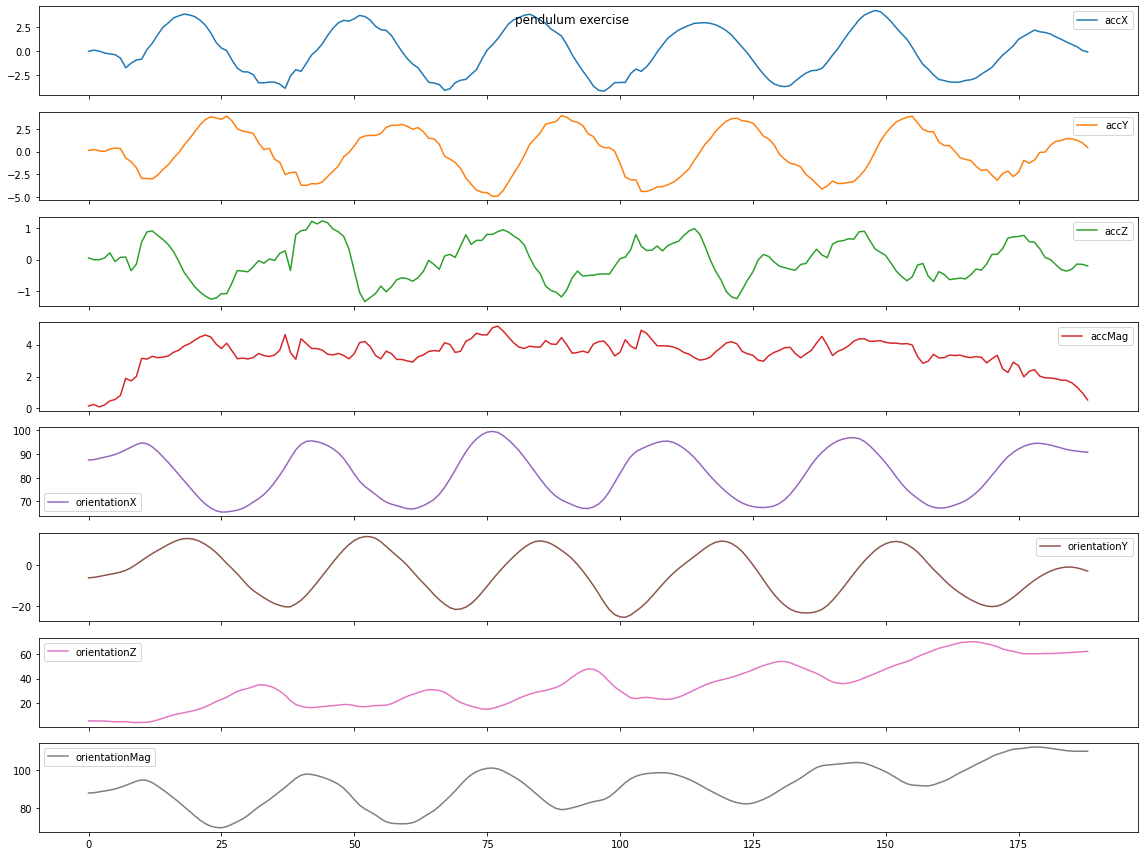

In [5]:
ex_type_idx = np.random.randint(40)
type_gym = sorted(os.listdir(data_folder))[ex_type_idx]
ex_idx = np.random.randint(len(os.listdir(data_folder+type_gym)))
ex_file =  os.listdir(data_folder+type_gym)[ex_idx]
df = pd.read_csv(data_folder+type_gym+'/'+ex_file)
df['accMag'] = df['accX']**2 + df['accY']**2 + df['accZ']**2
df['accMag'] = df['accMag']**(0.5)

df['orientationMag'] = df['orientationX']**2 + df['orientationY']**2 + df['orientationZ']**2
df['orientationMag'] = df['orientationMag']**(0.5)
df[features].plot(subplots=True, figsize = (16, 12), sharex=True, title=type_gym)
plt.tight_layout()
plt.show()

# Model Prediction and Speed Test

In [6]:
inp_out_prep(file_path = data_folder+type_gym+'/'+ex_file, model_type='tflite')

Ground truth:      pendulum exercise
Model prediction:  pendulum exercise
Prediction time for the given sample is  0.005 seconds!
